# Overview: Multirotor Drone Model

## Motivation

The `multirotor_drone` example model was developed to showcase how fmdtools can be used to design more resilient airspace systems starting at the earliest stages of design, including:

- Overall design of the **function architecture** and the selection of **component architectures** that fulfill given system functionality, answering questions like "how much redundancy is needed in the battery architecture?" for a given application

- Exploring and evaluating a wide range of concepts for a single system design, including different potential concepts of operations, answering questions like "can this drone that was previously been flown in rural areas be used to fly over buildings?"

## Model Setup

The drone model has one base model architecture defined in `model_static.py` that is extended in different variants add attributes to different functions (e.g., behaviors, component architectures, etc) as well as add functions.



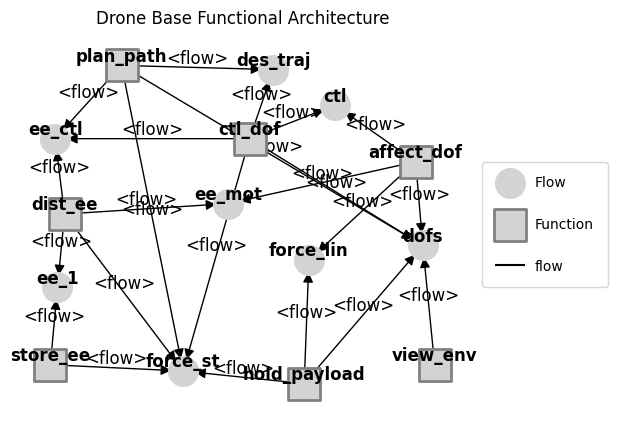

In [1]:
from model_static import Drone, pos
mg = Drone().as_modelgraph()
mg.pos = pos
fig, ax = mg.draw(title="Drone Base Functional Architecture", figsize=(6, 5))

## Study: Original fmdtools Paper

This drone was the main case study for the original fmdtools paper ["fmdtools: A fault propagation toolkit for resilience assessment in early design"](https://papers.phmsociety.org/index.php/ijphm/article/view/2954).

:::: {.columns}
::: {.column width="50%"}

This paper was able to showcase how fmdtools can be used both for network modeling and behavioral simulation at different levels of fidelity to support design, including:

- a static representation (only causes/effects)--see `model_static.py`

- a dynamic representation (system behavior)--see `model_dynamic.py`

- a hierarchical representation (with components)-- see `model_hierarchical.py`

:::
::: {.column width="50%"}
![](outputs_paper_ijphm_fmdtools/static_propagation.svg){fig-align="center"}

This notebook that produced this paper is located in `paper_ijphm_fmdtools.ipynb`
:::
::::




## Study: Optimization Architectures

The `model_rural.py` model was developed to showcase the resilience-based optimization of a drone surveying a rural area in a defined pattern. 

:::: {.columns}
::: {.column width="50%"}
The problem formulated involved the optimization of:

- battery and line architecture (e.g., quad, hex, and octorotor configuration)

- optimization of drone flight height (e.g., flying lower versus higher), and

- optimization of reconfiguration policies (e.g., fly home, emergency land, etc.) 
:::
::: {.column width="50%"}

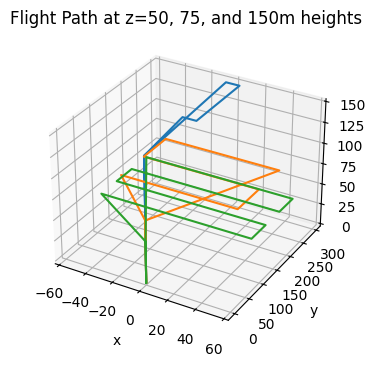

In [2]:
#| echo: false
from fmdtools.sim import propagate
from model_rural import Drone, plot_env_with_traj_z, plot_env_with_traj
from script_opt_model_rural import plan_flight
mdl = Drone(p={'flightplan': plan_flight(150)[0]})
res, hist = propagate.nominal(mdl)
fig, ax = hist.plot_trajectories("flows.dofs.s.x", "flows.dofs.s.y", "flows.dofs.s.z", legend=False)

mdl = Drone(p={'flightplan': plan_flight(75)[0]})
res, hist = propagate.nominal(mdl)
fig, ax = hist.plot_trajectories("flows.dofs.s.x", "flows.dofs.s.y", "flows.dofs.s.z", legend=False, fig=fig, ax=ax)

mdl = Drone(p={'flightplan': plan_flight(50)[0]})
res, hist = propagate.nominal(mdl)
fig, ax = hist.plot_trajectories("flows.dofs.s.x", "flows.dofs.s.y", "flows.dofs.s.z",  title = "Flight Path at z=50, 75, and 150m heights", legend=False, fig=fig, ax=ax)

:::
::::


This study was published in [Exploring Architectures for Integrated Resilience Optimization
](https://arc.aiaa.org/doi/full/10.2514/1.I010942)

## Extension to Urban Flight

This model has additionally been used to model urban flight scenarios, in the model `model_urban.py`. This model has a different environment from the "rural" model, including buildings and safe/unsafe places to land:

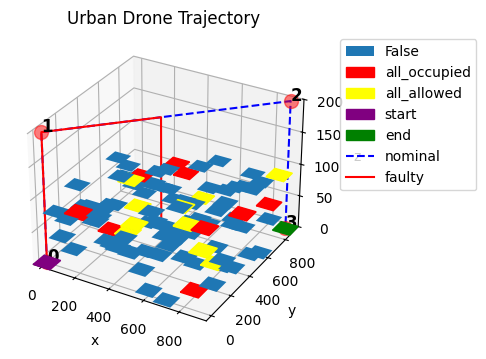

In [3]:
from model_urban import Drone, plot_env_with_traj_z
mdl = Drone(sp={'end_condition': 'scenario_finished'})
results_fault, hist_fault = propagate.one_fault(mdl, "affect_dof.ca.comps.lr", "mechbreak", time=1.4)
fig, ax = plot_env_with_traj_z(hist_fault, mdl, title = "Urban Drone Trajectory")

## Conclusions/Relevance

The `multirotor_drone` example showcases some basics of how fmdtools can be used through the course of a project to evaluate an aircraft's resilience to various hazardous scenarios.

This example shows how multiple models can be developed in the course of a design process to evaluate different potential concepts and usage scenarios. Because of fmdtools' use of object-oriented Python, these models can live independently while sharing common structures and behaviors. This makes it easy to (1) ensure consistency of evaluation (2) reduce technical debt and improve the ability to keep early design artifacts through the process and (3) make new models as new design considerations arise.

Much of this work has carried on into evaluating the airspace and multi-aircraft interactions, which led to the creation of the `/airspacelib` example.